# Data Visualization

## Objective
This notebook covers visual data analysis using Matplotlib, Seaborn, and Word Cloud libraries.


---

## 1. Setup & Data Loading

This section imports libraries, configures styles, and loads the preprocessed data.

In [1]:
import os
import ast
import warnings
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 11})

def save_plot(name):
    os.makedirs('../artifacts', exist_ok=True)
    path = f'../artifacts/{name}.png'
    plt.savefig(path, dpi=130, bbox_inches='tight')
    print(f'   Saved → {path}')

CLEANED_DATA_PATH = '../artifacts/cleaned_movies.csv'
if not os.path.exists(CLEANED_DATA_PATH):
    raise FileNotFoundError(f"Cleaned dataset not found at {CLEANED_DATA_PATH}. Please run 05_TMDB_EDA.ipynb first.")

movies = pd.read_csv(CLEANED_DATA_PATH)
print(f"Loaded dataset: {movies.shape[0]:,} rows.")
movies.head(2)

Loaded dataset: 48,806 rows.


,id,title,genres,overview,popularity,vote_average,vote_count,release_date,revenue,runtime,original_language,status,year,month,popularity_norm,vote_average_norm,vote_count_norm,popularity_zscore,vote_average_zscore
0,54778,Sea of Death,"Science Fiction, Thriller, Drama, TV Movie, Ac...",In the German North Sea a new cellular life fo...,1.678,4.2,13,2009-09-02,0,98,de,Released,2009.0,9.0,0.001071,0.42,0.000527,0.087313,0.916289
1,783222,Fuengirola,Unknown,Short documentary by the basque filmmaker Chum...,0.600,0.0,0,1967-01-01,0,13,es,Released,1967.0,1.0,0.000383,0.00,0.000000,-0.052735,-0.548034


---

## 2. Matplotlib Visualizations

This section creates release trends, rating distributions, genre counts, language area plots, and genre waffle charts.

   Saved → ../artifacts/viz_01_line.png


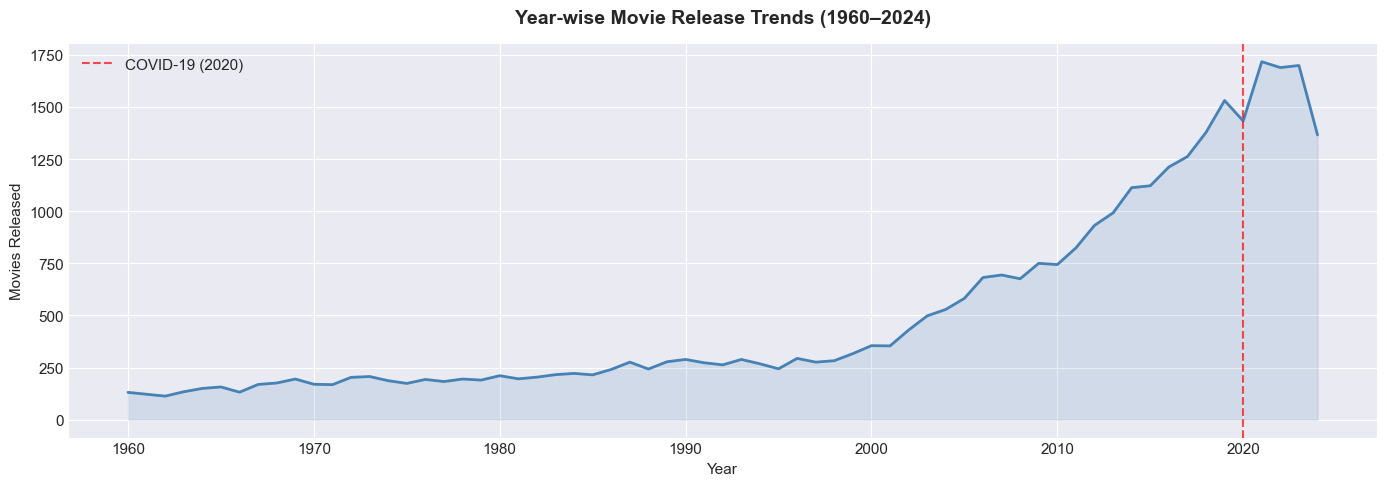

   Saved → ../artifacts/viz_02_histogram.png


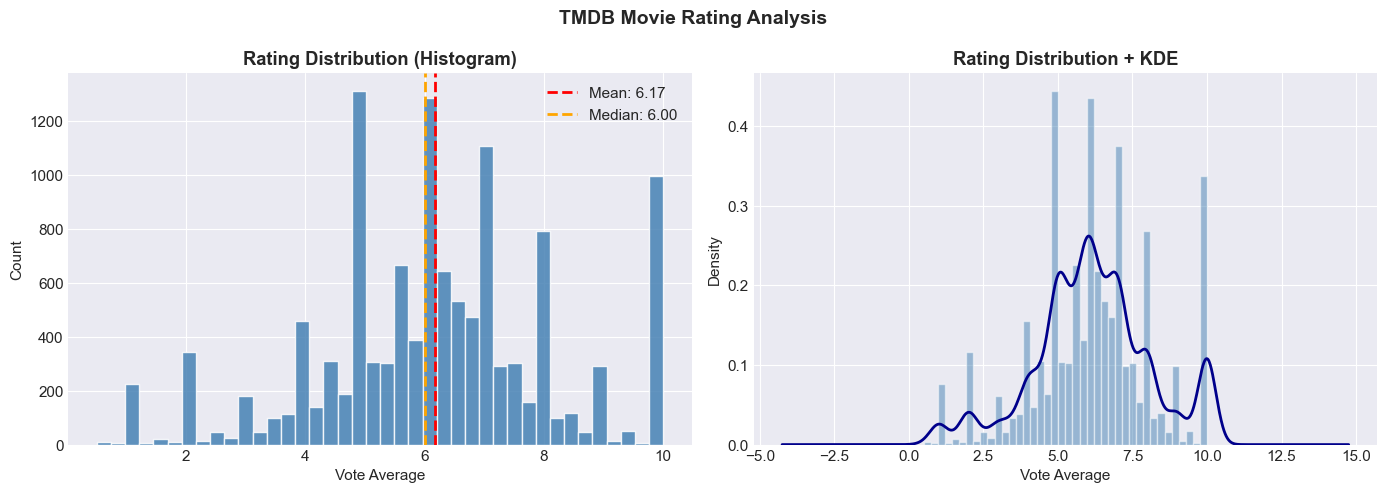

   Saved → ../artifacts/viz_03_bar.png


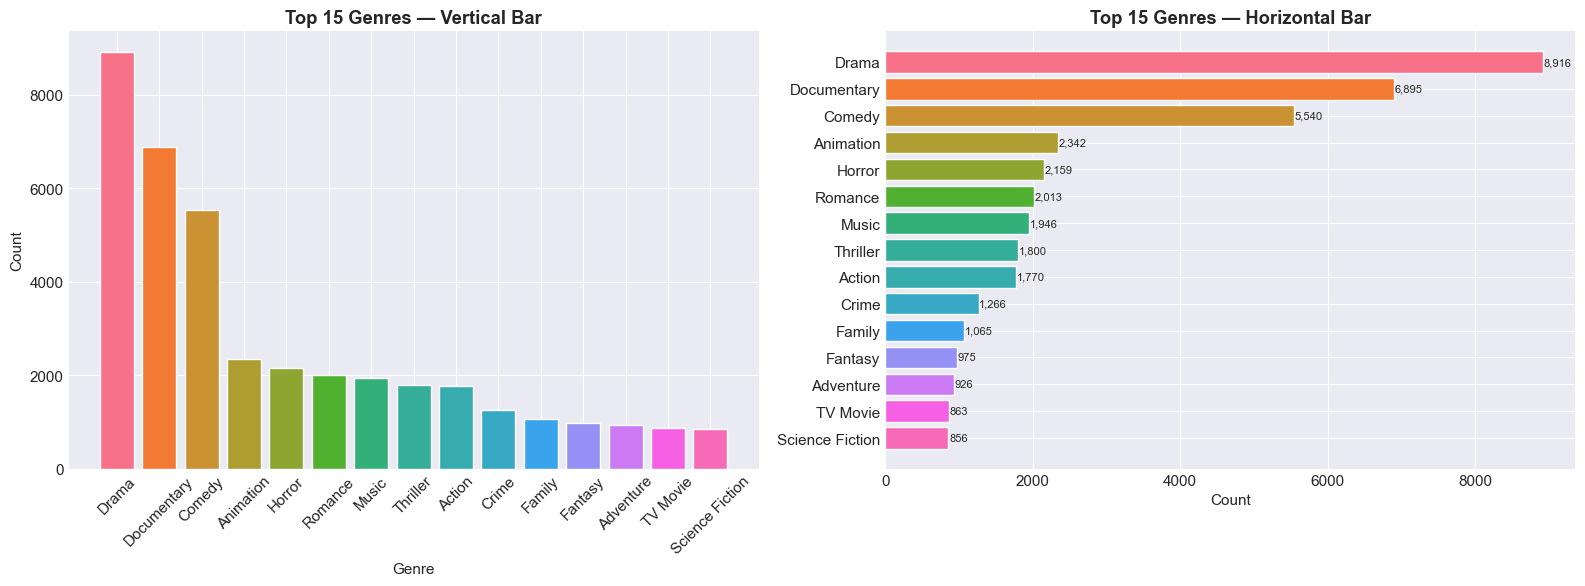

   Saved → ../artifacts/viz_04_area.png


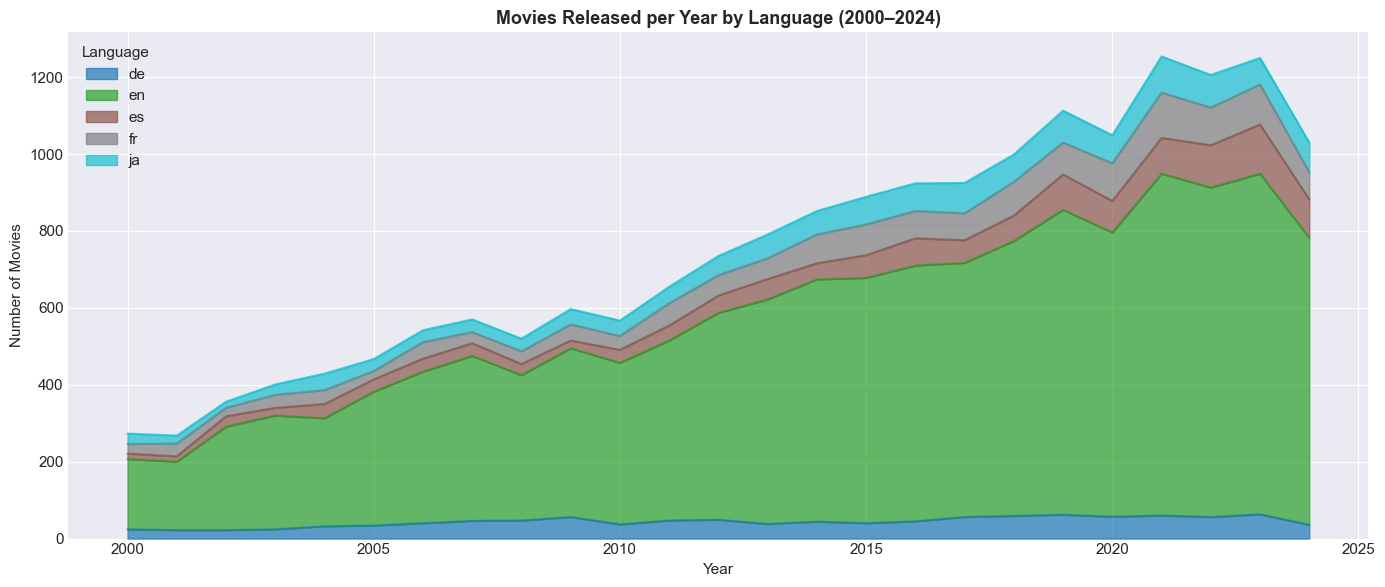

   Saved → ../artifacts/viz_05_waffle.png


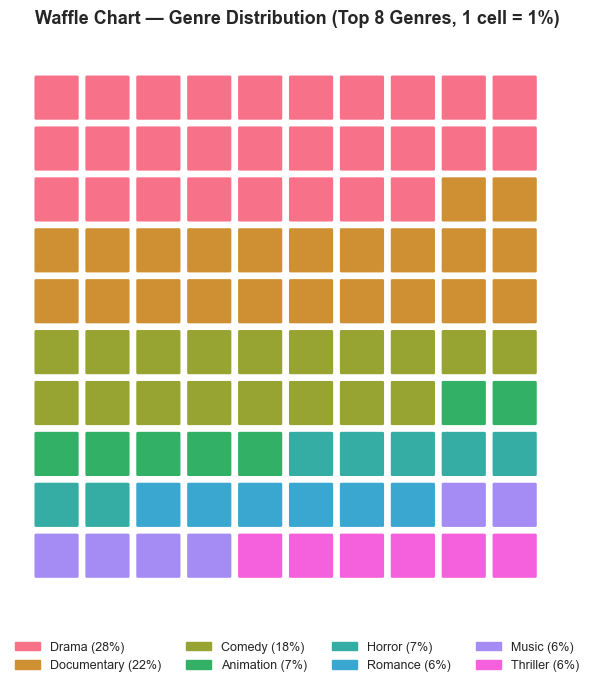

In [2]:
# ── 2.1 Line Plot ──
year_counts = (
    movies[(movies['year'] >= 1960) & (movies['year'] <= 2024)]
    .groupby('year').size()
)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(year_counts.index, year_counts.values, color='steelblue', linewidth=2)
ax.fill_between(year_counts.index, year_counts.values, alpha=0.15, color='steelblue')
ax.set_title('Year-wise Movie Release Trends (1960–2024)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year'); ax.set_ylabel('Movies Released')
ax.axvline(2020, color='red', linestyle='--', alpha=0.7, label='COVID-19 (2020)')
ax.legend()
plt.tight_layout(); save_plot('viz_01_line'); plt.show()

# ── 2.2 Histogram & KDE ──
rated = movies[movies['vote_average'] > 0]['vote_average']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(rated, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(rated.mean(),   color='red',    linestyle='--', lw=2, label=f'Mean: {rated.mean():.2f}')
axes[0].axvline(rated.median(), color='orange', linestyle='--', lw=2, label=f'Median: {rated.median():.2f}')
axes[0].set_title('Rating Distribution (Histogram)', fontweight='bold')
axes[0].set_xlabel('Vote Average'); axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(rated, bins=40, color='steelblue', edgecolor='white', alpha=0.5, density=True)
rated.plot.kde(ax=axes[1], color='darkblue', linewidth=2)
axes[1].set_title('Rating Distribution + KDE', fontweight='bold')
axes[1].set_xlabel('Vote Average'); axes[1].set_ylabel('Density')
plt.suptitle('TMDB Movie Rating Analysis', fontsize=14, fontweight='bold')
plt.tight_layout(); save_plot('viz_02_histogram'); plt.show()

# ── 2.3 Bar Charts ──
all_genres = []
for g in movies['genres'].dropna():
    if isinstance(g, str) and g not in ('Unknown', ''):
        if g.strip().startswith('['):
            try:
                items = ast.literal_eval(g)
                if items and isinstance(items[0], dict):
                    all_genres.extend([i.get('name','') for i in items])
                else:
                    all_genres.extend([str(i) for i in items])
            except Exception:
                all_genres.extend([x.strip() for x in g.split(',') if x.strip()])
        else:
            all_genres.extend([x.strip() for x in g.split(',') if x.strip()])

genre_counts = Counter(all_genres)
top_genres   = pd.Series(genre_counts).sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = sns.color_palette('husl', len(top_genres))
axes[0].bar(top_genres.index, top_genres.values, color=colors, edgecolor='white')
axes[0].set_title('Top 15 Genres — Vertical Bar', fontweight='bold')
axes[0].set_xlabel('Genre'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

axes[1].barh(top_genres.index[::-1], top_genres.values[::-1], color=colors[::-1], edgecolor='white')
axes[1].set_title('Top 15 Genres — Horizontal Bar', fontweight='bold')
axes[1].set_xlabel('Count')
for i, v in enumerate(top_genres.values[::-1]):
    axes[1].text(v + 10, i, f'{v:,}', va='center', fontsize=8)
plt.tight_layout(); save_plot('viz_03_bar'); plt.show()

# ── 2.4 Area Plot ──
if 'original_language' in movies.columns:
    top_langs = movies['original_language'].value_counts().head(5).index.tolist()
    area_data = (
        movies[(movies['year'] >= 2000) & (movies['year'] <= 2024)
               & (movies['original_language'].isin(top_langs))]
        .groupby(['year','original_language'])
        .size()
        .unstack(fill_value=0)
    )
    fig, ax = plt.subplots(figsize=(14, 6))
    area_data.plot.area(ax=ax, alpha=0.7, colormap='tab10')
    ax.set_title('Movies Released per Year by Language (2000–2024)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Year'); ax.set_ylabel('Number of Movies')
    ax.legend(title='Language', loc='upper left')
    plt.tight_layout(); save_plot('viz_04_area'); plt.show()

# ── 2.5 Waffle Chart ──
top8 = top_genres.head(8)
total = top8.sum()
proportions = (top8 / total * 100).round().astype(int)

waffle_data = []
for genre, count in proportions.items():
    waffle_data.extend([genre] * count)
waffle_data = waffle_data[:100]
while len(waffle_data) < 100:
    waffle_data.append(waffle_data[-1])

grid = np.array(waffle_data).reshape(10, 10)
unique_genres_w = top8.index.tolist()
palette = sns.color_palette('husl', len(unique_genres_w))
color_map = {g: palette[i] for i, g in enumerate(unique_genres_w)}

fig, ax = plt.subplots(figsize=(10, 7))
for r in range(10):
    for c in range(10):
        genre = grid[r, c]
        color = color_map.get(genre, (0.7, 0.7, 0.7))
        rect = mpatches.FancyBboxPatch(
            (c * 1.1, (9 - r) * 1.1), 0.9, 0.9,
            boxstyle='round,pad=0.05',
            facecolor=color, edgecolor='white', linewidth=1.5
        )
        ax.add_patch(rect)

legend_patches = [mpatches.Patch(color=color_map[g], label=f"{g} ({proportions.get(g,0)}%)") for g in unique_genres_w]
ax.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, -0.18), ncol=4, fontsize=9, frameon=False)
ax.set_xlim(-0.2, 11.5); ax.set_ylim(-0.2, 11.5)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('Waffle Chart — Genre Distribution (Top 8 Genres, 1 cell = 1%)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout(); save_plot('viz_05_waffle'); plt.show()

---

## 3. Word Cloud

This section generates a word cloud from movie descriptions.

   Saved → ../artifacts/viz_06_wordcloud.png


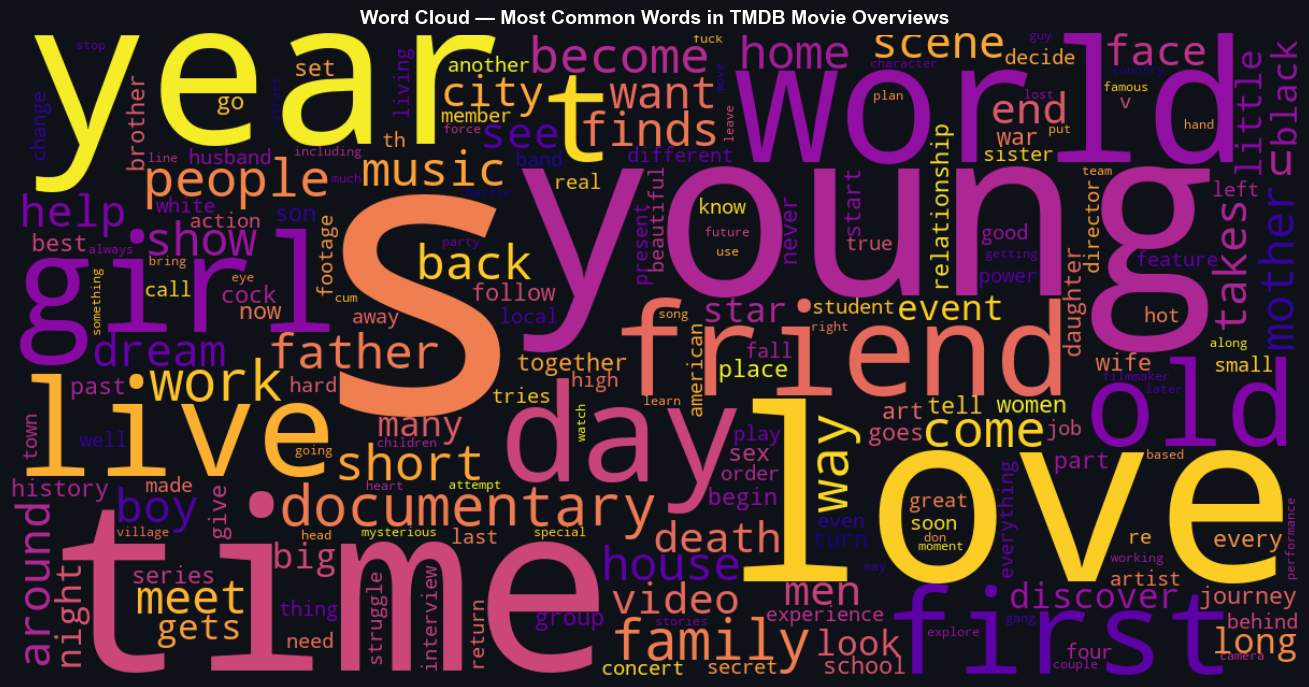

In [3]:
try:
    from wordcloud import WordCloud, STOPWORDS

    STOP = set(STOPWORDS) | {'film','movie','story','one','will','life','man','woman',
                              'new','get','find','make','also','two','three','must','take',
                              'No','overview','available'}

    text_corpus = ' '.join(
        movies['overview'].dropna()
                          .sample(min(3000, len(movies)), random_state=42)
                          .str.lower()
                          .str.replace(r'[^a-z\s]', ' ', regex=True)
    )

    wc = WordCloud(
        width=1200, height=600, background_color='#0e1117',
        colormap='plasma', max_words=200, stopwords=STOP,
        min_font_size=10, prefer_horizontal=0.9,
        collocations=False,
    ).generate(text_corpus)

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title('Word Cloud — Most Common Words in TMDB Movie Overviews',
                 fontsize=14, fontweight='bold', color='white',
                 bbox=dict(facecolor='#0e1117', edgecolor='none', pad=5))
    fig.patch.set_facecolor('#0e1117')
    plt.tight_layout(); save_plot('viz_06_wordcloud'); plt.show()

except ImportError:
    print("  wordcloud package not installed.")

---

## 4. Seaborn Visualizations

This section builds decade distributions (box/violin), popularity vs rating scatter, and correlation heatmaps.

   Saved → ../artifacts/viz_07_seaborn.png


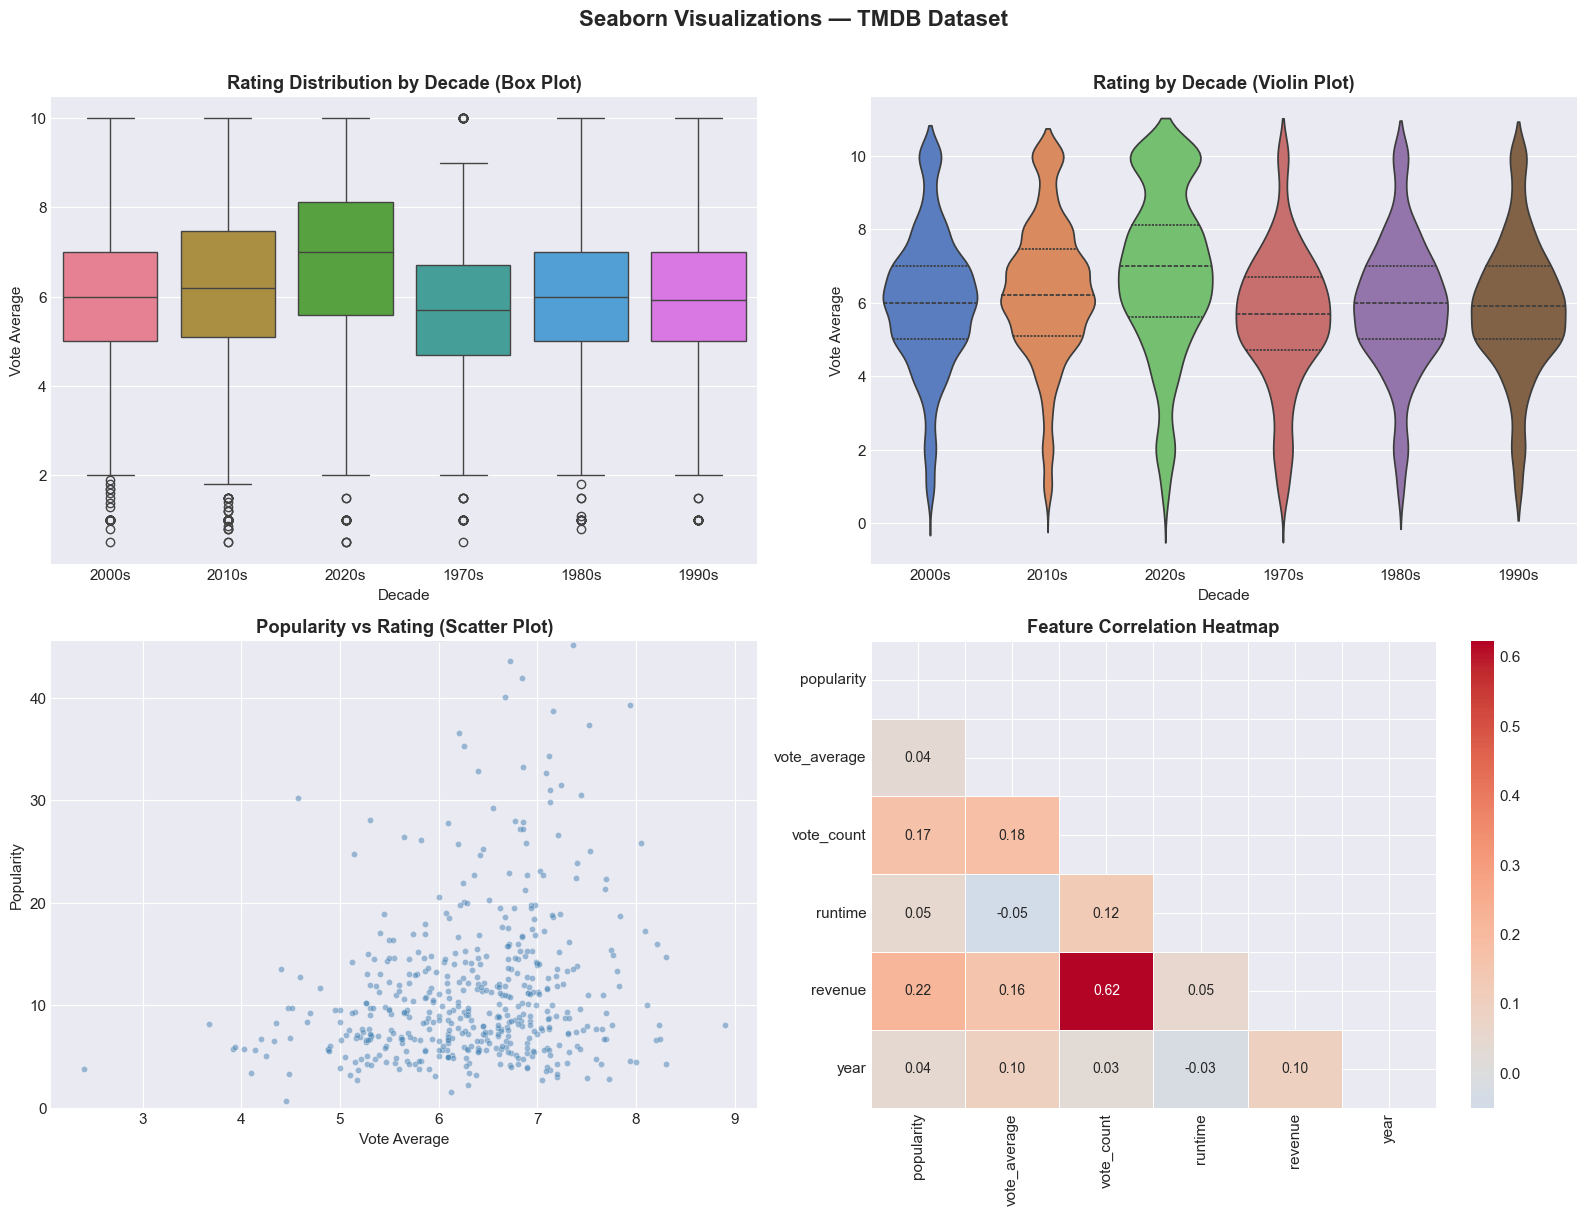

In [4]:
plot_df = movies[
    (movies['vote_average'] > 0) &
    (movies['popularity'] > 0) &
    (movies['vote_count'] >= 50)
].sample(min(3000, len(movies[
    (movies['vote_average'] > 0) &
    (movies['popularity'] > 0) &
    (movies['vote_count'] >= 50)
])), random_state=42)

movies_decade = movies.dropna(subset=['year']).copy()
movies_decade = movies_decade[
    (movies_decade['year'] >= 1970) & (movies_decade['year'] <= 2024) &
    (movies_decade['vote_average'] > 0)
].copy()
movies_decade['decade'] = (movies_decade['year'] // 10 * 10).astype(int).astype(str) + 's'

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.boxplot(data=movies_decade, x='decade', y='vote_average', palette='husl', ax=axes[0,0])
axes[0,0].set_title('Rating Distribution by Decade (Box Plot)', fontweight='bold')
axes[0,0].set_xlabel('Decade'); axes[0,0].set_ylabel('Vote Average')

sns.violinplot(data=movies_decade, x='decade', y='vote_average', palette='muted', inner='quartile', ax=axes[0,1])
axes[0,1].set_title('Rating by Decade (Violin Plot)', fontweight='bold')
axes[0,1].set_xlabel('Decade'); axes[0,1].set_ylabel('Vote Average')

sns.scatterplot(data=plot_df.sample(min(500, len(plot_df)), random_state=1), x='vote_average', y='popularity', alpha=0.5, s=20, color='steelblue', ax=axes[1,0])
axes[1,0].set_title('Popularity vs Rating (Scatter Plot)', fontweight='bold')
axes[1,0].set_xlabel('Vote Average'); axes[1,0].set_ylabel('Popularity')
axes[1,0].set_ylim(0, plot_df['popularity'].quantile(0.97))

num_cols = ['popularity','vote_average','vote_count']
if 'runtime' in movies.columns: num_cols.append('runtime')
if 'revenue' in movies.columns: num_cols.append('revenue')
if 'year'    in movies.columns: num_cols.append('year')
corr = movies[num_cols].replace(0, np.nan).dropna().corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, mask=mask, ax=axes[1,1], linewidths=0.5, annot_kws={'size': 10})
axes[1,1].set_title('Feature Correlation Heatmap', fontweight='bold')

plt.suptitle('Seaborn Visualizations — TMDB Dataset', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout(); save_plot('viz_07_seaborn'); plt.show()

---

## 5. Advanced Visualizations

This section builds movie status distribution (pie/donut), pairplots, and top revenue summaries.

   Saved → ../artifacts/viz_09_pie.png


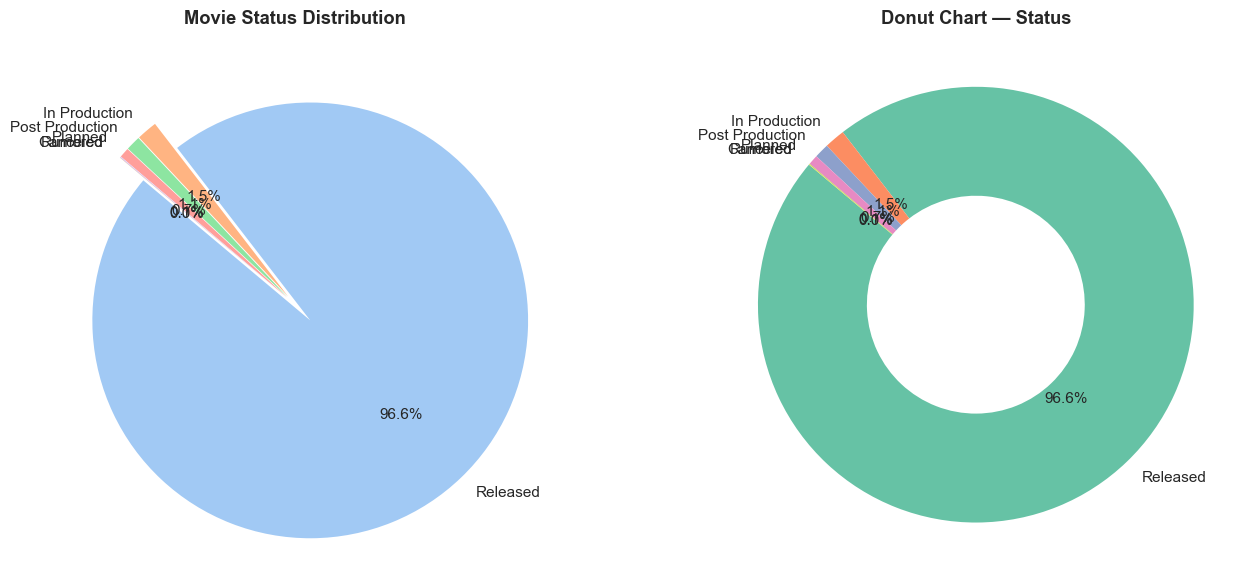

   Saved → ../artifacts/viz_10_pairplot.png


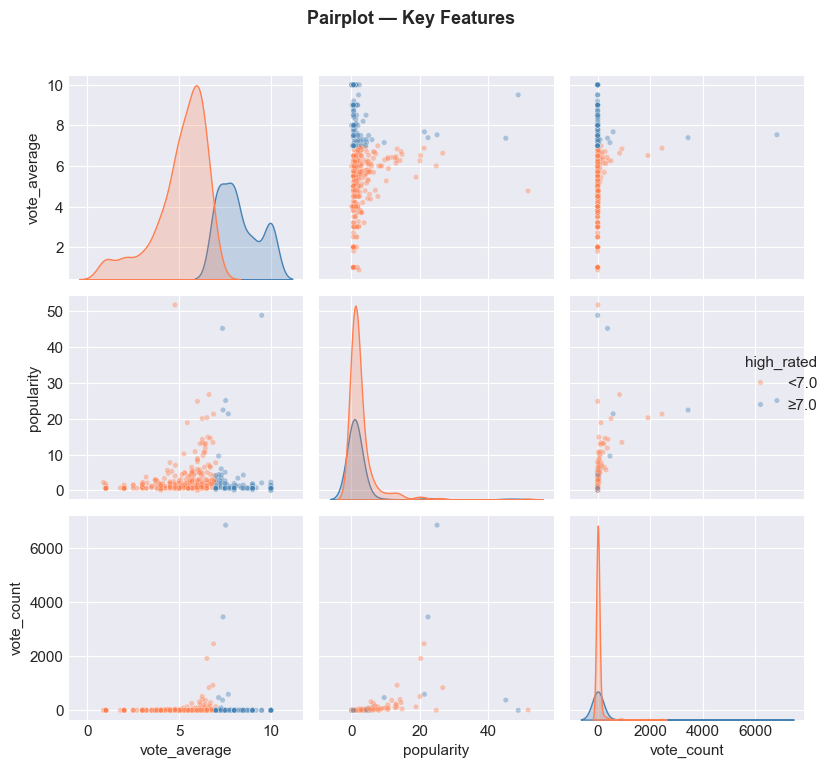

   Saved → ../artifacts/viz_11_revenue.png


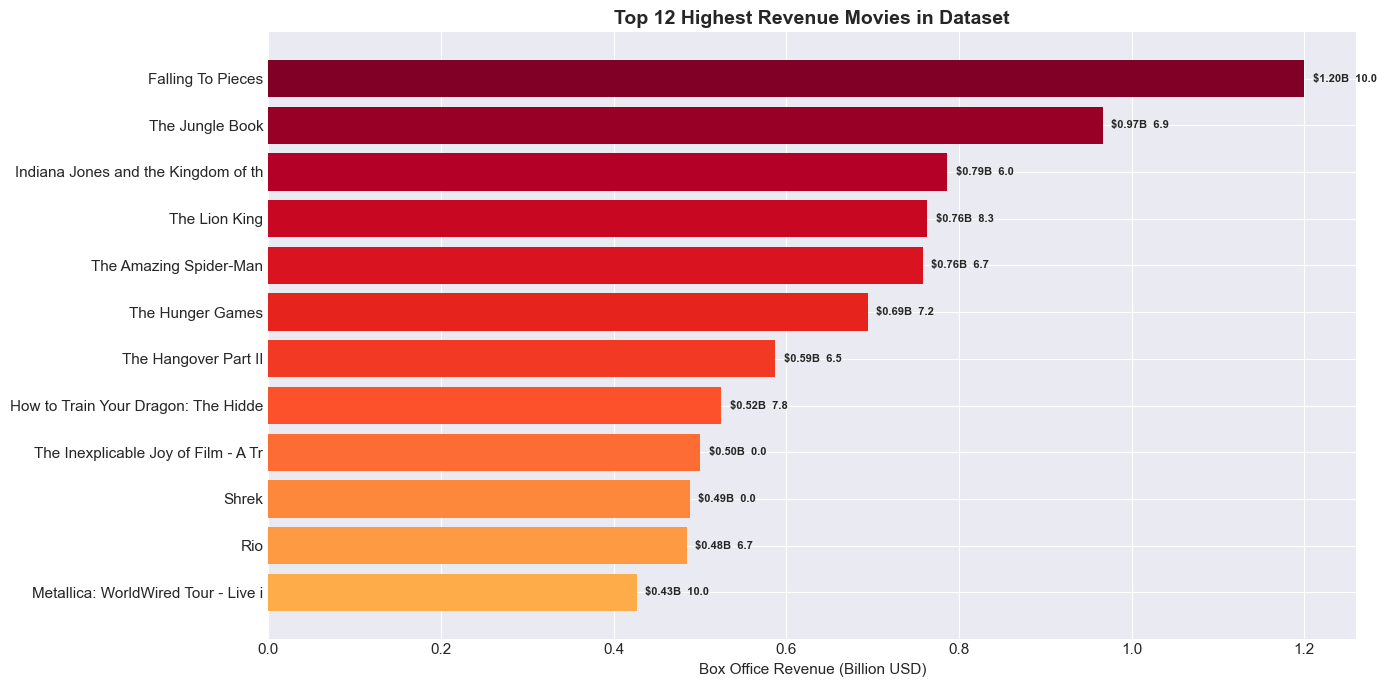

In [5]:
# ── 5.1 Status Charts ──
if 'status' in movies.columns:
    status_counts = movies['status'].value_counts()
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    explode = [0.05] * len(status_counts)
    explode[0] = 0.1
    axes[0].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'), explode=explode)
    axes[0].set_title('Movie Status Distribution', fontweight='bold')
    axes[1].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set2'), wedgeprops={'width': 0.5})
    axes[1].set_title('Donut Chart — Status', fontweight='bold')
    plt.tight_layout(); save_plot('viz_09_pie'); plt.show()

# ── 5.2 Pairplot ──
pair_df = movies[['vote_average','popularity','vote_count']].replace(0, np.nan).dropna().sample(min(500, len(movies)), random_state=42)
pair_df['high_rated'] = (pair_df['vote_average'] >= 7.0).map({True:'≥7.0', False:'<7.0'})
g = sns.pairplot(pair_df, hue='high_rated', palette={'≥7.0':'steelblue','<7.0':'coral'}, plot_kws={'alpha':0.4, 's':15}, diag_kind='kde')
g.fig.suptitle('Pairplot — Key Features', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs('../artifacts', exist_ok=True)
g.savefig('../artifacts/viz_10_pairplot.png', dpi=100, bbox_inches='tight')
print('   Saved → ../artifacts/viz_10_pairplot.png')
plt.show()

# ── 5.3 Revenue Chart ──
if 'revenue' in movies.columns:
    top_rev = movies[movies['revenue'] > 1_000_000].nlargest(12, 'revenue')
    top_rev['revenue_B'] = top_rev['revenue'] / 1e9
    fig, ax = plt.subplots(figsize=(14, 7))
    colors = plt.cm.YlOrRd(np.linspace(0.4, 1.0, len(top_rev)))
    bars = ax.barh(top_rev['title'].str[:35][::-1], top_rev['revenue_B'].values[::-1], color=colors)
    ax.set_xlabel('Box Office Revenue (Billion USD)')
    ax.set_title('Top 12 Highest Revenue Movies in Dataset', fontsize=14, fontweight='bold')
    for bar, (_, row) in zip(bars, top_rev[::-1].iterrows()):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'${row["revenue_B"]:.2f}B  {row["vote_average"]:.1f}',
                va='center', fontsize=8, fontweight='bold')
    plt.tight_layout(); save_plot('viz_11_revenue'); plt.show()